In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jainilcoder/netflix-stock-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\heman\.cache\kagglehub\datasets\jainilcoder\netflix-stock-price-prediction\versions\1


In [29]:
import os
import pandas as pd

# See files inside folder
print(os.listdir(path))

# Load CSV (check exact file name from above output)
df = pd.read_csv(path + "/NFLX.csv")

print(df.head())

['NFLX.csv']
         Date        Open        High         Low       Close   Adj Close  \
0  2018-02-05  262.000000  267.899994  250.029999  254.259995  254.259995   
1  2018-02-06  247.699997  266.700012  245.000000  265.720001  265.720001   
2  2018-02-07  266.579987  272.450012  264.329987  264.559998  264.559998   
3  2018-02-08  267.079987  267.619995  250.000000  250.100006  250.100006   
4  2018-02-09  253.850006  255.800003  236.110001  249.470001  249.470001   

     Volume  
0  11896100  
1  12595800  
2   8981500  
3   9306700  
4  16906900  


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [31]:
data = df.tail(30)

In [32]:
data['Day'] = np.arange(1, len(data) + 1)

C:\Users\heman\AppData\Local\Temp\ipykernel_21620\1687398655.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Day'] = np.arange(1, len(data) + 1)


In [33]:
X = data[['Day']].values
y = data['Close'].values

In [34]:
degree = 3
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)

In [35]:
model = LinearRegression()
model.fit(X_poly, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
next_day = np.array([[31]])
next_day_poly = poly.transform(next_day)
predicted_price = model.predict(next_day_poly)

print(f"Predicted Netflix closing price for next day: {predicted_price[0]:.2f}")


Predicted Netflix closing price for next day: 438.76


In [37]:
X_range = np.linspace(1, 31, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_pred = model.predict(X_range_poly)

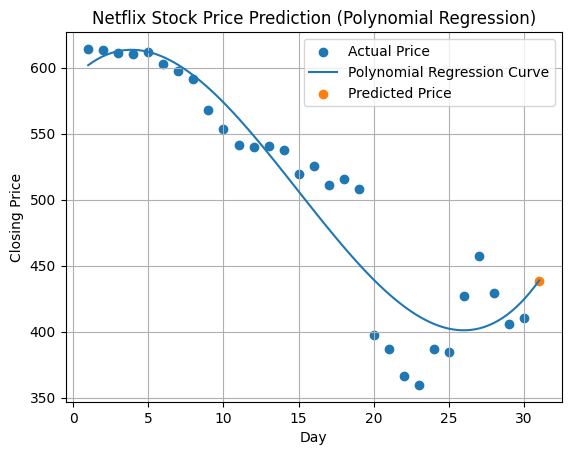

In [42]:
plt.scatter(X, y, label="Actual Price")
plt.plot(X_range, y_pred, label="Polynomial Regression Curve")
plt.scatter(31, predicted_price, label="Predicted Price")
plt.xlabel("Day")
plt.ylabel("Closing Price")
plt.title("Netflix Stock Price Prediction (Polynomial Regression)")
plt.legend()
plt.grid()

plt.show()